In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Box plots of intrinsic dimension 

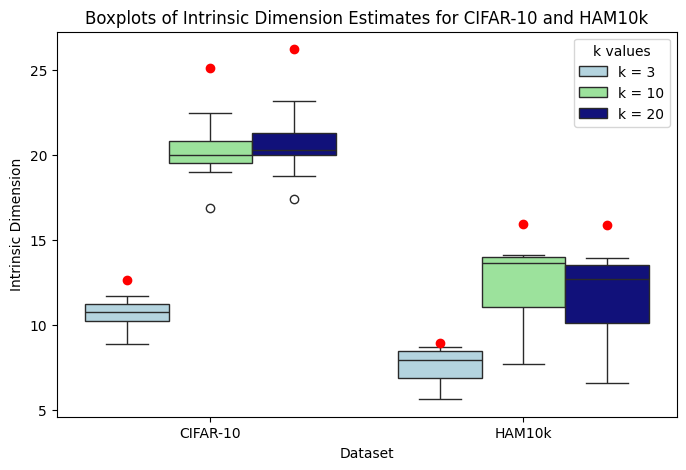

In [2]:
# Define k values
ks = [3, 10, 20]  

cifar10_dims = {3: [8.87, 10.12, 11, 10.71, 10.38, 11.4, 10.03, 11.29, 10.76, 11.71], 
                10: [16.84, 19.44, 20.06, 19.76, 19.87, 20.84, 20.87, 20.80, 18.95, 22.43],
                20: [17.37, 20.09, 20.22, 19.97, 20.30, 20.95, 21.75, 21.38, 18.76, 23.14]}

ham10k_dims = {3: [8.70, 8.48, 8.39, 5.88, 7.81, 7.91, 5.61],
                10: [13.63, 13.55, 14.07, 8.5, 13.93, 14.03, 7.66],
                20: [12.7, 12.53, 13.57, 7.61, 13.42, 13.94, 6.59]}

cifar10_full = {3: [12.63], 10: [25.07], 20: [26.2]}
ham10k_full = {3: [8.92], 10: [15.89], 20: [15.86]}

# Create a DataFrame
df_list = []
for k in ks:
    df_list.append(pd.DataFrame({
        "Intrinsic Dimension": np.concatenate([cifar10_dims[k], ham10k_dims[k]]),
        "Dataset": ["CIFAR-10"] * len(cifar10_dims[k]) + ["HAM10k"] * len(ham10k_dims[k]),
        "k": [f"k = {k}"] * (len(cifar10_dims[k]) + len(ham10k_dims[k]))
    }))
df = pd.concat(df_list)

# Create the box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x="Dataset", y="Intrinsic Dimension", hue="k", data=df, palette=["lightblue", "lightgreen", "darkblue"])

# Get base x-tick positions (centers of CIFAR-10 and HAM10k)
x_ticks = np.array(ax.get_xticks())  

# Compute offsets for each k using Seaborn's internal spacing
num_k = len(ks)
box_group_width = 0.8  # Total width of grouped boxes (Seaborn default)
spacing = np.linspace(-box_group_width / 3, box_group_width / 3, num_k)  # Compute exact offsets

# Plot the red dots at the correct locations
for i, k in enumerate(ks):
    plt.scatter(
        x_ticks + spacing[i],  # Shift red dots precisely to center of each k box
        [cifar10_full[k], ham10k_full[k]],  
        color="red",
        zorder=3,
        label=None
    )

# Labels and legend
plt.ylabel("Intrinsic Dimension")
plt.legend(title="k values")
plt.title("Boxplots of Intrinsic Dimension Estimates for CIFAR-10 and HAM10k")

plt.show()


Note that the intrinsic dimension estimator tends to underestimate for smaller datasets/classes. Also note that our estimates for CIFAR-10 are quite different from the original paper, and the only reason I can think of for this is that I normalize the images

## Correlation between class intrinsic dimension and test accuracy

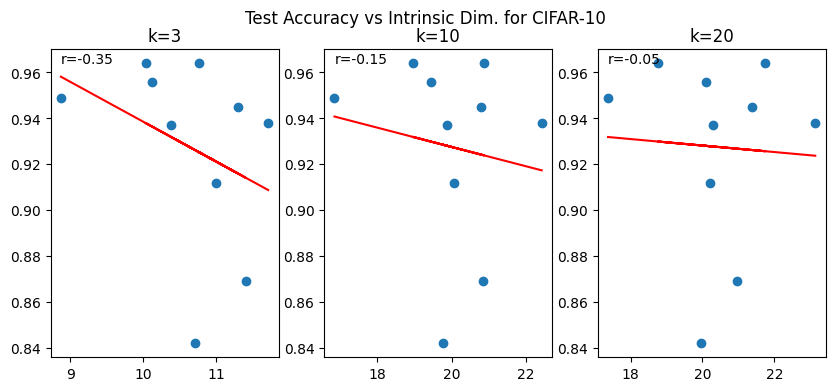

In [3]:
cifar10_accs = [0.949, 0.956, 0.912, 0.842, 0.937, 0.869, 0.964, 0.945, 0.964, 0.938]

fig, ax = plt.subplots(1, 3, figsize=(10,4))
for idx, k in enumerate(ks):
    x = cifar10_dims[k]
    y = cifar10_accs
    ax[idx].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[idx].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[idx].plot(x, regression_line, color="red")
    ax[idx].set_title(f"k={k}")
fig.suptitle("Test Accuracy vs Intrinsic Dim. for CIFAR-10")
plt.show()

Need to get correlation results for CIFAR-10 using more models.

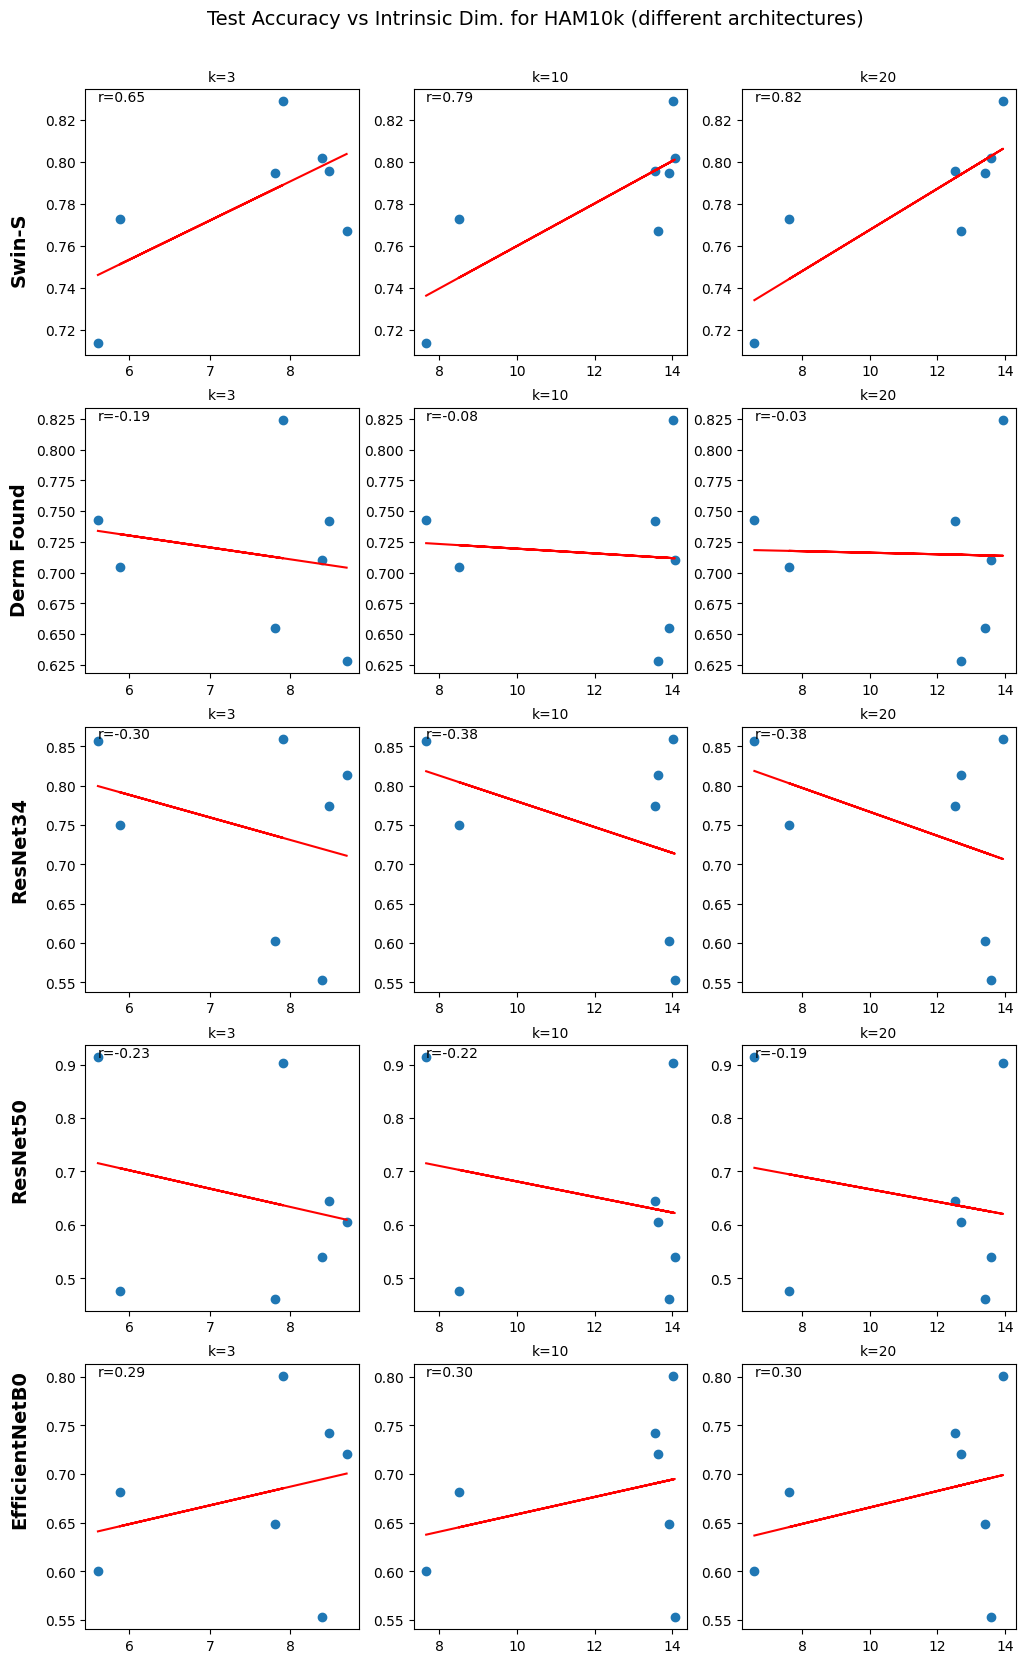

In [4]:
ham10k_accs = [[0.767, 0.796, 0.802, 0.773, 0.795, 0.829, 0.714],
                [0.628, 0.742, 0.710, 0.705, 0.655, 0.824, 0.743],
                [0.814, 0.774, 0.553, 0.750, 0.602, 0.860, 0.857],
                [0.605, 0.645, 0.539, 0.477, 0.462, 0.904, 0.914],
                [0.721, 0.742, 0.553, 0.682, 0.649, 0.801, 0.600]
            ]
row_titles = ["Swin-S", "Derm Found", "ResNet34", "ResNet50", "EfficientNetB0"]
title_locations = np.linspace(0.8,0.2,5)

fig, ax = plt.subplots(5, 3, figsize=(12,20))
for i in range(len(ks) * len(ham10k_accs)):
    row = i // len(ks)
    col = i % len(ks)
    x = ham10k_dims[ks[col]]
    y = ham10k_accs[row]
    ax[row, col].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[row, col].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[row, col].plot(x, regression_line, color="red")
    ax[row, col].set_title(f"k={ks[col]}", fontsize=10)

    if (i+1) % 3 == 0:
        fig.text(
            x=0.07,  # Adjust as needed
            y=title_locations[row],  # Center the title in the row
            s=row_titles[row],
            va="center",
            ha="center",
            fontsize=14,
            fontweight="bold",
            rotation=90  # Rotate to align with rows
        )

fig.suptitle("Test Accuracy vs Intrinsic Dim. for HAM10k (different architectures)", fontsize=14, y=0.92)
plt.show()


The correlation results are all over the place, for some architectures we have a negative correlation (which is what expect based on the observations in the paper) while for others like the Swin model (which was the best performing model) there is a strong positive correlation.

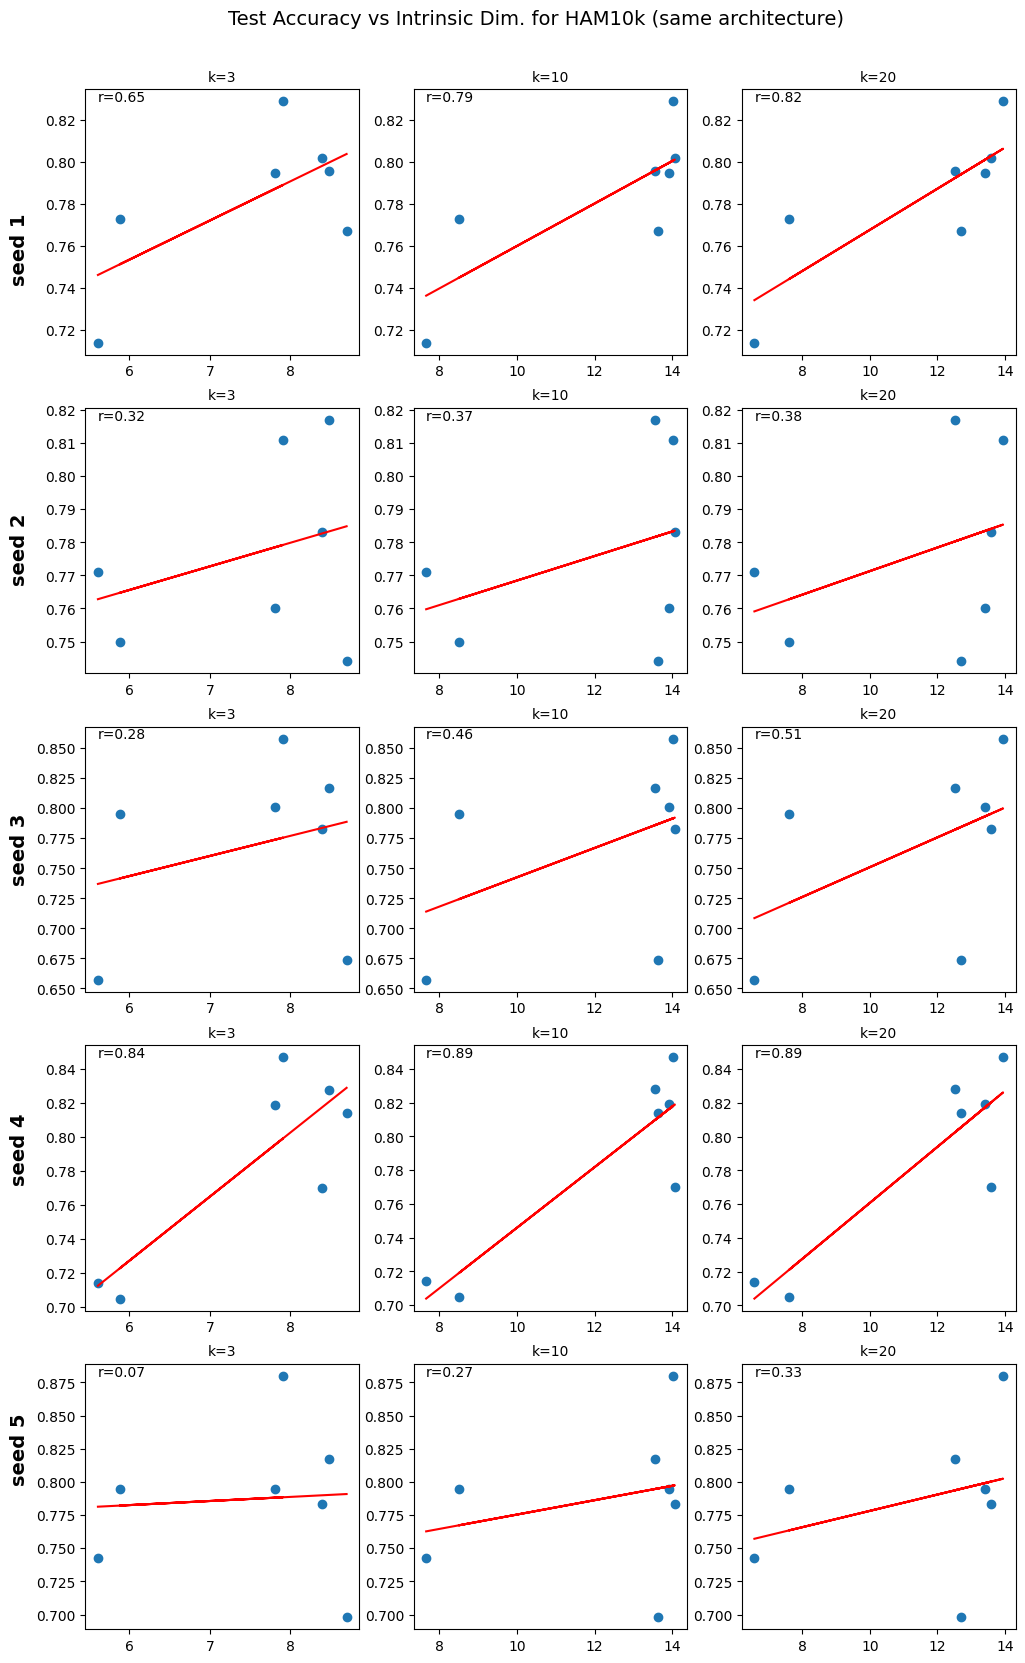

In [5]:
ham10k_accs = [[0.767, 0.796, 0.802, 0.773, 0.795, 0.829, 0.714],
                [0.744, 0.817, 0.783, 0.750, 0.760, 0.811, 0.771],
                [0.674, 0.817, 0.783, 0.795, 0.801, 0.858, 0.657],
                [0.814, 0.828, 0.770, 0.705, 0.819, 0.847, 0.714],
                [0.698, 0.817, 0.783, 0.795, 0.795, 0.880, 0.743]
            ]
row_titles = ["seed 1", "seed 2", "seed 3", "seed 4", "seed 5"]
title_locations = np.linspace(0.8,0.2,5)

fig, ax = plt.subplots(5, 3, figsize=(12,20))
for i in range(len(ks) * len(ham10k_accs)):
    row = i // len(ks)
    col = i % len(ks)
    x = ham10k_dims[ks[col]]
    y = ham10k_accs[row]
    ax[row, col].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[row, col].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[row, col].plot(x, regression_line, color="red")
    ax[row, col].set_title(f"k={ks[col]}", fontsize=10)

    if (i+1) % 3 == 0:
        fig.text(
            x=0.07,  # Adjust as needed
            y=title_locations[row],  # Center the title in the row
            s=row_titles[row],
            va="center",
            ha="center",
            fontsize=14,
            fontweight="bold",
            rotation=90  # Rotate to align with rows
        )

fig.suptitle("Test Accuracy vs Intrinsic Dim. for HAM10k (same architecture)", fontsize=14, y=0.92)
plt.show()

## Box plots of intrinsic dimension in embedding space

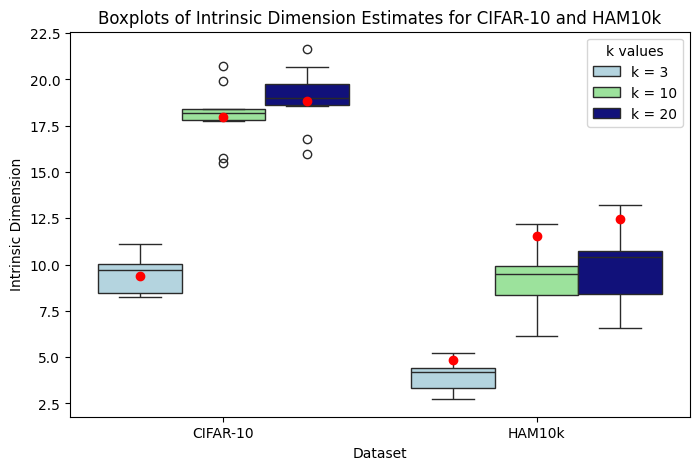

In [6]:
# Define k values
ks = [3, 10, 20]  

cifar10_dims = {3: [8.34, 9.81, 8.25, 10.83, 8.75, 9.56, 8.40, 10.09, 9.83, 11.11], 
                10: [15.76, 18.41, 15.49, 20.70, 17.76, 18.15, 18.29, 18.05, 18.25, 19.90],
                20: [16.79, 19.03, 15.99, 21.63, 19.00, 18.97, 20.02, 18.57, 18.84, 20.68]}

ham10k_dims = {3: [4.55, 4.22, 4.24, 2.73, 3.56, 5.25, 3.12],
                10: [9.50, 9.97, 9.89, 6.17, 9.29, 12.21, 7.48],
                20: [9.46, 10.83, 10.63, 6.56, 10.43, 13.20, 7.33]}

cifar10_full = {3: [9.41], 10: [17.96], 20: [18.84]}
ham10k_full = {3: [4.86], 10: [11.54], 20: [12.46]}

# Create a DataFrame
df_list = []
for k in ks:
    df_list.append(pd.DataFrame({
        "Intrinsic Dimension": np.concatenate([cifar10_dims[k], ham10k_dims[k]]),
        "Dataset": ["CIFAR-10"] * len(cifar10_dims[k]) + ["HAM10k"] * len(ham10k_dims[k]),
        "k": [f"k = {k}"] * (len(cifar10_dims[k]) + len(ham10k_dims[k]))
    }))
df = pd.concat(df_list)

# Create the box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x="Dataset", y="Intrinsic Dimension", hue="k", data=df, palette=["lightblue", "lightgreen", "darkblue"])

# Get base x-tick positions (centers of CIFAR-10 and HAM10k)
x_ticks = np.array(ax.get_xticks())  

# Compute offsets for each k using Seaborn's internal spacing
num_k = len(ks)
box_group_width = 0.8  # Total width of grouped boxes (Seaborn default)
spacing = np.linspace(-box_group_width / 3, box_group_width / 3, num_k)  # Compute exact offsets

# Plot the red dots at the correct locations
for i, k in enumerate(ks):
    plt.scatter(
        x_ticks + spacing[i],  # Shift red dots precisely to center of each k box
        [cifar10_full[k], ham10k_full[k]],  
        color="red",
        zorder=3,
        label=None
    )

# Labels and legend
plt.ylabel("Intrinsic Dimension")
plt.legend(title="k values")
plt.title("Boxplots of Intrinsic Dimension Estimates for CIFAR-10 and HAM10k")

plt.show()

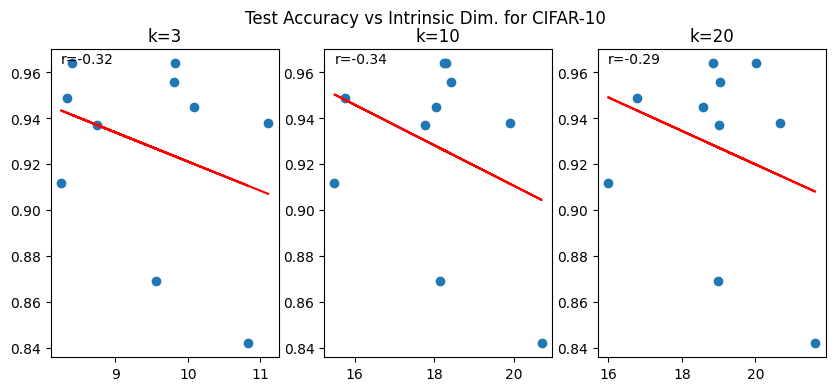

In [7]:
cifar10_accs = [0.949, 0.956, 0.912, 0.842, 0.937, 0.869, 0.964, 0.945, 0.964, 0.938]

fig, ax = plt.subplots(1, 3, figsize=(10,4))
for idx, k in enumerate(ks):
    x = cifar10_dims[k]
    y = cifar10_accs
    ax[idx].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[idx].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[idx].plot(x, regression_line, color="red")
    ax[idx].set_title(f"k={k}")
fig.suptitle("Test Accuracy vs Intrinsic Dim. for CIFAR-10")
plt.show()

Stronger negative correlation than intrinsic dimension in the image space

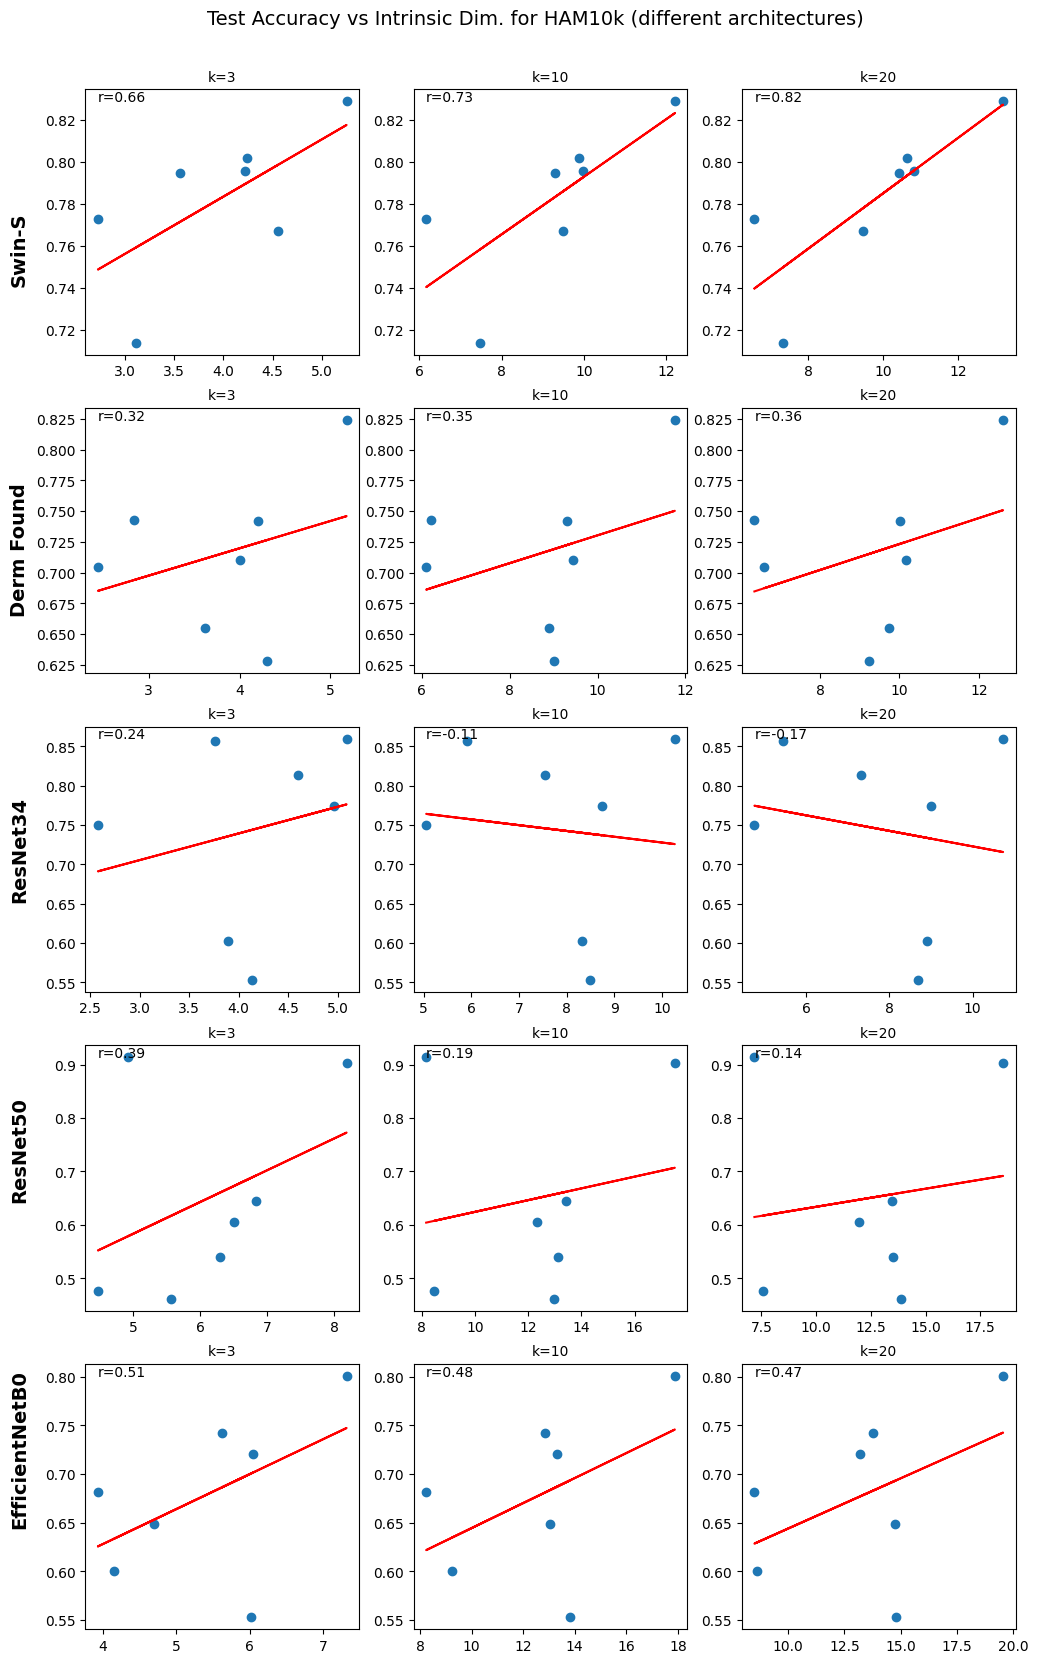

In [8]:
ham10k_dims = {'Swin-S': {3: [4.55, 4.22, 4.24, 2.73, 3.56, 5.25, 3.12],
                        10: [9.50, 9.97, 9.89, 6.17, 9.29, 12.21, 7.48],
                        20: [9.46, 10.83, 10.63, 6.56, 10.43, 13.20, 7.33]},
                'Derm Found': {3: [4.3, 4.2, 4, 2.44, 3.62, 5.18, 2.84], 
                               10: [9, 9.3, 9.44, 6.1, 8.89, 11.76, 6.2], 
                               20: [9.24, 10.01, 10.16, 6.60, 9.74, 12.61, 6.35]},
                'ResNet34': {3: [4.6, 4.96, 4.14, 2.58, 3.89, 5.09, 3.76], 
                             10: [7.55, 8.74, 8.49, 5.05, 8.32, 10.27, 5.90], 
                             20: [7.31, 9.01, 8.68, 4.76, 8.9, 10.73, 5.44]},
                'ResNet50': {3: [6.5, 6.83, 6.3, 4.48, 5.56, 8.18, 4.93], 
                             10: [12.31, 13.41, 13.1, 8.46, 12.97, 17.51, 8.16], 
                             20: [11.94, 13.45, 13.5, 7.57, 13.89, 18.54, 7.18]},
                'EfficientNetB0': {3: [6.04, 5.62, 6.01, 3.93, 4.69, 7.32, 4.15], 
                                   10: [13.32, 12.84, 13.81, 8.24, 13.04, 17.88, 9.25], 
                                   20: [13.21, 13.78, 14.78, 8.51, 14.75, 19.54, 8.62]}
                }

ham10k_accs = [[0.767, 0.796, 0.802, 0.773, 0.795, 0.829, 0.714],
                [0.628, 0.742, 0.710, 0.705, 0.655, 0.824, 0.743],
                [0.814, 0.774, 0.553, 0.750, 0.602, 0.860, 0.857],
                [0.605, 0.645, 0.539, 0.477, 0.462, 0.904, 0.914],
                [0.721, 0.742, 0.553, 0.682, 0.649, 0.801, 0.600]
            ]
row_titles = list(ham10k_dims.keys())
title_locations = np.linspace(0.8,0.2,5)

fig, ax = plt.subplots(5, 3, figsize=(12,20))
for i in range(len(ks) * len(ham10k_accs)):
    row = i // len(ks)
    col = i % len(ks)
    x = ham10k_dims[row_titles[row]][ks[col]]
    y = ham10k_accs[row]
    ax[row, col].scatter(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    regression_line = slope * np.array(x) + intercept
    correlation_coefficient = np.corrcoef(x, y)[0, 1]
    ax[row, col].text(min(x), max(y), f"r={correlation_coefficient:.2f}", fontsize=10, color="black")
    ax[row, col].plot(x, regression_line, color="red")
    ax[row, col].set_title(f"k={ks[col]}", fontsize=10)

    if (i+1) % 3 == 0:
        fig.text(
            x=0.07,  # Adjust as needed
            y=title_locations[row],  # Center the title in the row
            s=row_titles[row],
            va="center",
            ha="center",
            fontsize=14,
            fontweight="bold",
            rotation=90  # Rotate to align with rows
        )

fig.suptitle("Test Accuracy vs Intrinsic Dim. for HAM10k (different architectures)", fontsize=14, y=0.92)
plt.show()

Note that there are more positive correlations when computing intrinsic dimension in the embedding space compared to the image space. Also note that for ResNet50 and EfficientNetB0 the intrinsic dimension is actually higher in the embedding space.